In [7]:
import h5py
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import  numpy as np


LOGIT_TO_PHONEME = [
    'BLANK',
    'AA', 'AE', 'AH', 'AO', 'AW',
    'AY', 'B',  'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G',
    'HH', 'IH', 'IY', 'JH', 'K',
    'L', 'M', 'N', 'NG', 'OW',
    'OY', 'P', 'R', 'S', 'SH',
    'T', 'TH', 'UH', 'UW', 'V',
    'W', 'Y', 'Z', 'ZH',
    ' | ',
]

LOGIT_DICT = {i: ph for i, ph in enumerate(LOGIT_TO_PHONEME)}


def load_h5py_file(file_path):
    data = {
        'neural_features': [],
        'n_time_steps': [],
        'seq_class_ids': [],
        'seq_len': [],
        'transcriptions': [],
        'sentence_label': [],
        'session': [],
        'block_num': [],
        'trial_num': [],
    }
    # Open the hdf5 file for that day
    with h5py.File(file_path, 'r') as f:

        keys = list(f.keys())

        # For each trial in the selected trials in that day
        for key in keys:
            g = f[key]

            neural_features = g['input_features'][:]
            n_time_steps = g.attrs['n_time_steps']
            seq_class_ids = g['seq_class_ids'][:] if 'seq_class_ids' in g else None
            seq_len = g.attrs['seq_len'] if 'seq_len' in g.attrs else None
            transcription = g['transcription'][:] if 'transcription' in g else None
            sentence_label = g.attrs['sentence_label'][:] if 'sentence_label' in g.attrs else None
            session = g.attrs['session']
            block_num = g.attrs['block_num']
            trial_num = g.attrs['trial_num']
            data['neural_features'].append(neural_features)
            data['n_time_steps'].append(n_time_steps)
            data['seq_class_ids'].append(seq_class_ids)
            data['seq_len'].append(seq_len)
            data['transcriptions'].append(transcription)
            data['sentence_label'].append(sentence_label)
            data['session'].append(session)
            data['block_num'].append(block_num)
            data['trial_num'].append(trial_num)
    return data

#!ls ../data/brain/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11

data = load_h5py_file('data/brain/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11/data_train.hdf5')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'data/brain/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11/data_train.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

trial_num = 40
neural_features = data['neural_features'][trial_num].T
time = data['n_time_steps'][trial_num]
print("Duration", time * 0.02)
time = np.linspace(0, 0.02*time, time)  # seconds
sentence = data['sentence_label'][trial_num]
phonemes = data['seq_class_ids'][trial_num]



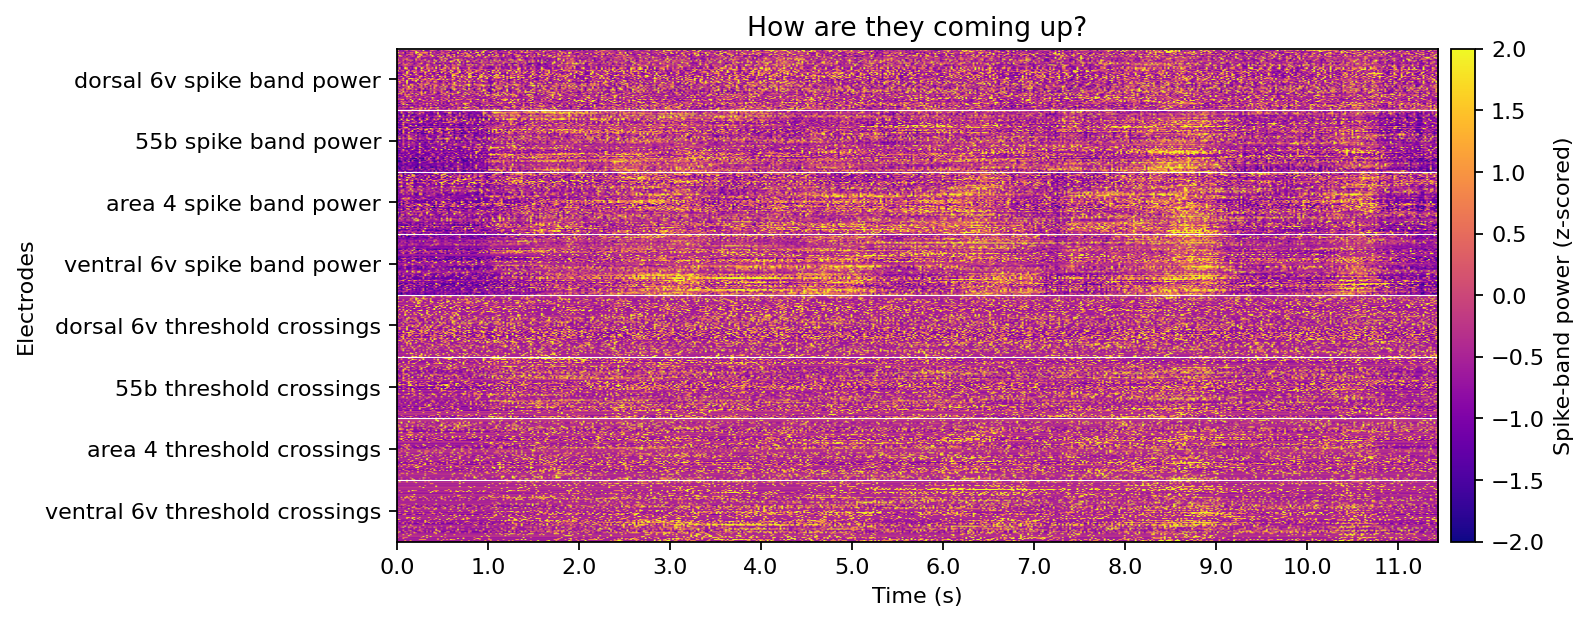

Phonemes: ['HH', 'AW', ' | ', 'AA', 'R', ' | ', 'DH', 'EY', ' | ', 'K', 'AH', 'M', 'IH', 'NG', ' | ', 'AH', 'P', ' | ']


In [9]:



# Electrode groups
groups = [
    (0, 64), (65, 128), (129, 192), (193, 256),
    (257, 320), (321, 384), (385, 448), (449, 512)
]

group_labels = [
    "ventral 6v threshold crossings",
    "area 4 threshold crossings",
    "55b threshold crossings",
    "dorsal 6v threshold crossings",
    "ventral 6v spike band power",
    "area 4 spike band power",
    "55b spike band power",
    "dorsal 6v spike band power"
]

fig, ax = plt.subplots(figsize=(10, 4), dpi=160)

# Heatmap
norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)
im = ax.imshow(
    neural_features, aspect='auto', origin='lower',
    extent=[time[0], time[-1], 0, 512],
    cmap='plasma', norm=norm
)

# Group separators
for (start, end) in groups:
    ax.hlines(end, time[0], time[-1], color='white', linewidth=0.5)

# Y-ticks at group midpoints with labels
mid_idxs = [0.5*(s+e) for s, e in groups]
ax.set_yticks(mid_idxs)
ax.set_yticklabels(group_labels)

# X-ticks every 0.5 seconds
xticks = np.arange(time[0], time[-1] , 1)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{t:.1f}" for t in xticks])

# Labels
ax.set_xlabel("Time (s)")
ax.set_ylabel("Electrodes")

# Colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label("Spike-band power (z-scored)")

plt.title(sentence)

plt.show()
print("Phonemes:", [LOGIT_DICT[int(p)] for p in phonemes if LOGIT_DICT[int(p)] != 'BLANK'])
